# Simple Display

This notebook is a simple displayer of a titan dunes terrain mask, and some restricted BRDFs (both simulated and observational) of Titan.

## Terrain Mask

Nothing complicated here, just a simple cell displaying the used terrain mask.

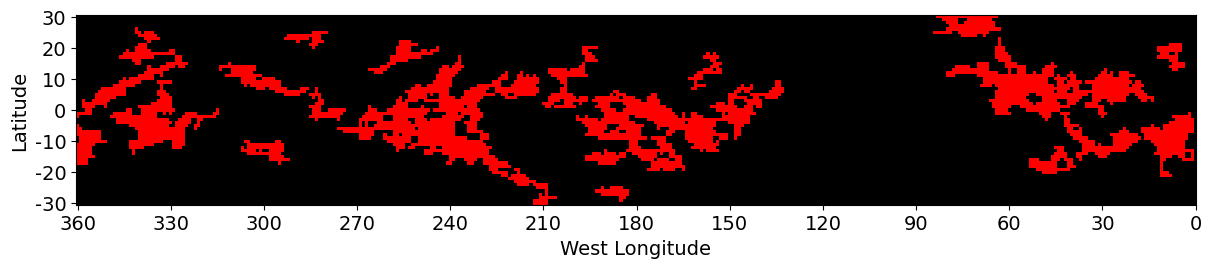

In [3]:
import numpy as np
import matplotlib.pyplot as plt

loadFile = np.load("DunesMask.npy")

lonTicks = [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360]
lonLabels = ["360", "330", "300", "270", "240", "210", "180", "150", "120", "90", "60", "30", "0"]

fig, ax = plt.subplots(figsize = (12,3),layout="constrained")
image = ax.imshow(loadFile)
ax.set_yticks([0, 10, 20, 30, 40, 50, 60])
ax.set_yticklabels(["30", "20", "10", "0", "-10", "-20", "-30"])
ax.set_ylabel("Latitude", fontsize=14)
ax.set_xticks(lonTicks)
ax.set_xticklabels(lonLabels)
ax.set_xlabel("West Longitude", fontsize=14)
ax.set_facecolor("black")
#ax.set(title = "Titan Surface Terrain Mask")

ax.tick_params(axis='both', labelsize=14)

#plt.savefig("TitanSurfaceMaskDunes.pdf", format="pdf", bbox_inches='tight')
#Uncomment if you want to regenerate the figure for some reason.

## Restricted BRDFs

This will be a bit more complicated, and will take multiple cells to get across. The first cell is where you tell the program what BRDFs you want to look at: simply comment out any row you don't want to consider. We have the 0.0, 0.1, and 0.2 albedo simulations, as well as the restricted BRDFs for the HLS and equatorial dunes. 

The second cell displays everything input in the first cell, but you have to manually scrub through the three viewing angles, and all wavelengths will be plotted on top of each other. You can select from the menu which viewing angle you wish to skewer over. This is best for only looking at a handful of files at once.

The third cell only works if you're looking at all wavelengths of every restricted BRDF you want to examine; it plots one in each of the eight sub-plots. However, unlike the first cell, it does not have sliders and only prints out what observation angles you input. This is best for looking at large scale behaviors.



In [15]:
#LOAD MODEL CELL
# COMMENT OUT ANYTHING YOU DON'T WANT TO SEE IN THIS LIST BEFORE RUNNING THE CELL
modelNames = [
    #HLS
    #["HLSFixedWindows0.93um.npy","Huygens Landing Site 0.9um"],
    #["HLSFixedWindows1.08um.npy","Huygens Landing Site 1um"],
    #["HLSFixedWindows1.27um.npy","Huygens Landing Site 1.3um"],
    #["HLSFixedWindows1.59um.npy","Huygens Landing Site 1.6um"],
    #["HLSFixedWindows2.01um.npy","Huygens Landing Site 2 microns"],
    #["HLSFixedWindows2.69um.npy","Huygens Landing Site 2.7um"],
    #["HLSFixedWindows2.79um.npy","Huygens Landing Site 2.8um"],
    #["HLSFixedWindows5MIXum.npy","Huygens Landing Site 5um"], #Using MIX instead of an individual wavelength to reduce SNR.

    #LAMBERTIAN MODEL SIMULATIONS
    ["newDooseA0.0LambSim0.93um.npy","Lambertian Model 0.9um A0.0"],
    ["newDooseA0.0LambSim1.08um.npy","Lambertian Model 1um A0.0"],
    ["newDooseA0.0LambSim1.27um.npy","Lambertian Model 1.3um A0.0"],
    ["newDooseA0.0LambSim1.59um.npy","Lambertian Model 1.6um A0.0"],
    ["newDooseA0.0LambSim2.01um.npy","Lambertian Model 2um A0.0"],
    ["newDooseA0.0LambSim2.69um.npy","Lambertian Model 2.7um A0.0"],
    ["newDooseA0.0LambSim2.79um.npy","Lambertian Model 2.8um A0.0"],
    ["newDooseA0.0LambSim5.00um.npy","Lambertian Model 5um A0.0"],

    ["newDooseA0.1LambSim0.93um.npy","Lambertian Model 0.9um A0.1"],
    ["newDooseA0.1LambSim1.08um.npy","Lambertian Model 1um A0.1"],
    ["newDooseA0.1LambSim1.27um.npy","Lambertian Model 1.3um A0.1"],
    ["newDooseA0.1LambSim1.59um.npy","Lambertian Model 1.6um A0.1"],
    ["newDooseA0.1LambSim2.01um.npy","Lambertian Model 2um A0.1"],
    ["newDooseA0.1LambSim2.69um.npy","Lambertian Model 2.7um A0.1"],
    ["newDooseA0.1LambSim2.79um.npy","Lambertian Model 2.8um A0.1"],
    ["newDooseA0.1LambSim5.00um.npy","Lambertian Model 5um A0.1"],

    ["newDooseA0.2LambSim0.93um.npy","Lambertian Model 0.9um A0.2"],
    ["newDooseA0.2LambSim1.08um.npy","Lambertian Model 1um A0.2"],
    ["newDooseA0.2LambSim1.27um.npy","Lambertian Model 1.3um A0.2"],
    ["newDooseA0.2LambSim1.59um.npy","Lambertian Model 1.6um A0.2"],
    ["newDooseA0.2LambSim2.01um.npy","Lambertian Model 2um A0.2"],
    ["newDooseA0.2LambSim2.69um.npy","Lambertian Model 2.7um A0.2"],
    ["newDooseA0.2LambSim2.79um.npy","Lambertian Model 2.8um A0.2"],
    ["newDooseA0.2LambSim5.00um.npy","Lambertian Model 5um A0.2"],

    #EQUATORIAL DATA BY TERRAIN
    ["equatorDunesFixedWins0.93um.npy","Equatorial Dunes 0.9um"],
    ["equatorDunesFixedWins1.08um.npy","Equatorial Dunes 1um"],
    ["equatorDunesFixedWins1.27um.npy","Equatorial Dunes 1.3um"],
    ["equatorDunesFixedWins1.59um.npy","Equatorial Dunes 1.6um"],
    ["equatorDunesFixedWins2.01um.npy","Equatorial Dunes 2 microns"],
    ["equatorDunesFixedWins2.69um.npy","Equatorial Dunes 2.7um"],
    ["equatorDunesFixedWins2.79um.npy","Equatorial Dunes 2.8um"],
    ["equatorDunesFixedWins5MIXum.npy","Equatorial Dunes 5um"],  #Using MIX instead of an individual wavelength to reduce SNR.
    
 
]

import csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import math
import os

#Add more files to load in as you desire. The format for doing so should be self-evident.

loadedModels = []
for filename in modelNames:
    truename = "RestrictedBRDFs\\" + filename[0]
    loadedModels.append(np.load(truename)) #The first name is the one we want, the second is just a label.

#Clean the models, some may retain nans or -1 values. Set these to 0. 
#originally the code was able to handle these but I have no idea what I changed to break it. So we clean them here.
i,j,k,m = 0,0,0,0
while (m < len(loadedModels)):
    i = 0
    while (i < len(loadedModels[0])):
        j = 0
        while (j < len(loadedModels[0][0])):
            k = 0
            while (k < len(loadedModels[0][0][0])):
                if (math.isnan(loadedModels[m][i][j][k] )):
                    loadedModels[m][i][j][k]  = 0
                elif (loadedModels[m][i][j][k] < 0):
                    loadedModels[m][i][j][k] = 0
                if (modelNames[m][0] == "SpecularModel2.00um.npy" or modelNames[m][0] == "LambertianModel2.00um.npy"):
                    loadedModels[m][i][j][k] = loadedModels[m][i][j][k]*8. #The older models need this correcting factor.
                k = k+1
            j = j+1
        i = i+1
    m = m+1

#we have supplemental information files we may wish to access and compare to the loadedModels. 

loadedModelCounts = [] #How many times did we hit each point in reality? Used to identify which points are real data and not interpolated.
loadedModelCubs = [] #In case you wanted to know which cubes were used. Note that some cubes are repated, due to being used a ton of times. This
# was not originally intentional but we have decided to keep it as it allows us to "weight" cubes involved in certain situations.
loadedModelStdevs = []

for filename in modelNames:
    truename = "..\\ModelCreator\\" + filename[0].removesuffix(".npy") + "Counts.npy"
    if os.path.isfile(truename): loadedModelCounts.append(np.load(truename)) 
    else: loadedModelCounts.append("N") #Single character because strings are read as arrays, fun. N for NO. 

for filename in modelNames:
    truename = "..\\ModelCreator\\" + filename[0].removesuffix(".npy") + "Cubs.npy"
    if os.path.isfile(truename): loadedModelCubs.append(np.load(truename, allow_pickle = True)) #REMEMBER THE PICKLE
    else: loadedModelCubs.append("N") 

for filename in modelNames:
    truename = "..\\ModelCreator\\" + filename[0].removesuffix(".npy") + "Stdev.npy"
    if os.path.isfile(truename): loadedModelStdevs.append(np.load(truename)) 
    else: loadedModelStdevs.append([[[0 for x in range(37)] for x in range(19)] for x in range(21)]) #Sometimes this doesn't exist, make sure indices still match. 

#No need to clean these as they will be supplementary to the loadedModels, you won't read them without the models.

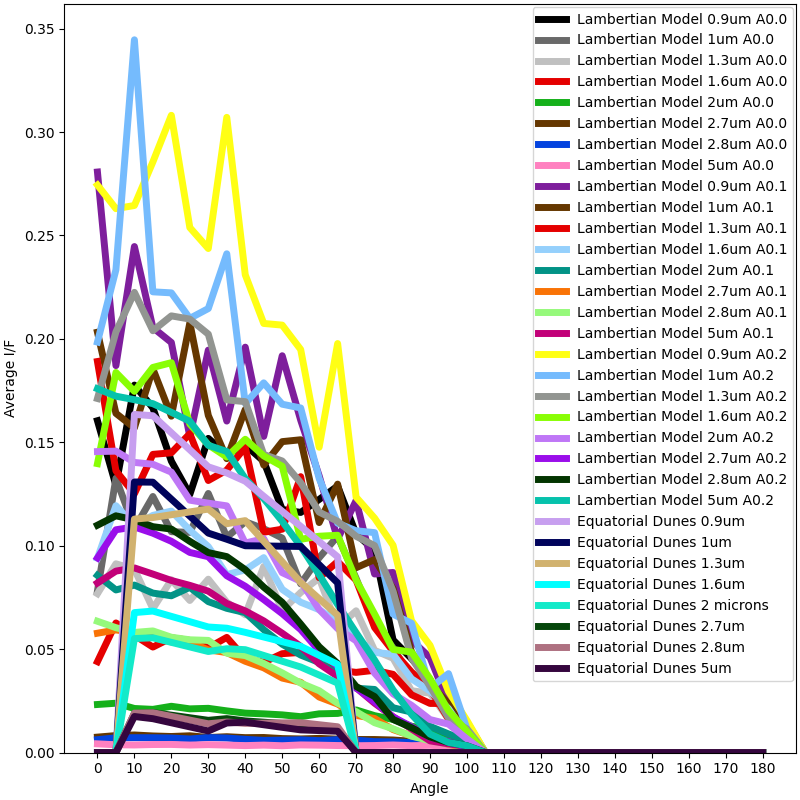

In [16]:
#CELL 4: OMNI DISPLAY: DISPLAYS ALL DATA AT ONCE ADJUSTABLE WITH SLIDERS.
#NOTE: currently, displaying more things has to be hardcoded in. Yes, it sucks. 
#There has to be a way to genrealize it.
%matplotlib ipympl 
#Allows animation and interaction.

plt.close()

angleSpace = np.linspace(0, 180, 37)
inciSpace = np.linspace(0, 100, 21)
emisSpace = np.linspace(0, 90, 19)
azimSpace = np.linspace(0, 180, 37)
typeSpace = {("inci", "emis", "azim")}

class ControlPlottingManager:
    models = len(loadedModels) #To keep the compiler from complaining about an empty class.
    #This class exists soley so I can store dynamically created functions in it.
    #I blame mpl_interactions.ipyplot for this, every funciton it plots has to be separately defined. 

i = 0
while (i < len(loadedModels)): #This loop here dynamically constructs a unique function for every line we want to plot.
    exec(
'''def controllablePlotter1(inci,emis,azim,types):
    theLine = []
    inci =int(inci/5)
    emis =int(emis/5)
    azim =int(azim/5)
    model = 1
    mod = 1 #Or 8???

    i = 0
    if (types == "inci"):
        while (i < 21):
            theLine.append(loadedModels[''' + str(i) + '''][i][emis][azim]*mod)
            i=i+1
    if (types == "emis"):
        while (i < 19):
            theLine.append(loadedModels[''' + str(i) + '''][inci][i][azim]*mod)
            i=i+1
    if (types == "azim"):
        while (i < 37):
            theLine.append(loadedModels[''' + str(i) + '''][inci][emis][i]*mod)
            i=i+1

    while (i < 37):
        theLine.append(0.)
        i=i+1
    
    return theLine
    
def controllablePlotter2(inci,emis,azim,types): #FOR SCATTERING PLOTS!
    theLine = []
    dummyX = []
    inci =int(inci/5)
    emis =int(emis/5)
    azim =int(azim/5)
    model = 1
    mod = 1 #Or 8???

    i = 0
    if (types == "inci"):
        while (i < 21):
            theLine.append(loadedModels[''' + str(i) + '''][i][emis][azim]*mod)
            dummyX.append(i)
            i=i+1
    if (types == "emis"):
        while (i < 19):
            theLine.append(loadedModels[''' + str(i) + '''][inci][i][azim]*mod)
            dummyX.append(i)
            i=i+1
    if (types == "azim"):
        while (i < 37):
            theLine.append(loadedModels[''' + str(i) + '''][inci][emis][i]*mod)
            dummyX.append(i)
            i=i+1

    while (i < 37):
        theLine.append(0.)
        dummyX.append(i)
        i=i+1
    
    return dummyX, theLine'''
    )
    setattr(ControlPlottingManager, 'modelFunc' + str(i), controllablePlotter1)
    setattr(ControlPlottingManager, 'scatterFunc' + str(i), controllablePlotter2)
    i=i+1

angleLabels = [0, 10, 20, 30, 40, 50, 60, 70,
             80, 90, 100, 110, 120, 130, 140, 150,
             160, 170, 180] 

ticker = [0,2,4,6,8,10,12,14,16,18,20,22,24,26,28,30,32,34,36]

#colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:gray", 
         #"tab:olive", "tab:cyan", "k", "peru", "darkgreen", "skyblue", "navy", "blueviolet", "magenta", "palegreen", 
          #"teal", "purple"]

#So it turns out we did need a lot of colors eventually. 
colors = [ "black", "dimgray", "silver", "xkcd:red", "xkcd:green", "xkcd:brown", "xkcd:blue", "xkcd:pink", "xkcd:purple", "xkcd:brown", "xkcd:red",
         "xkcd:light blue", "xkcd:teal", "xkcd:orange", "xkcd:light green", "xkcd:magenta", "xkcd:yellow",
         "xkcd:sky blue", "xkcd:grey", "xkcd:lime green", "xkcd:light purple", "xkcd:violet", "xkcd:dark green",
         "xkcd:turquoise", "xkcd:lavender", "xkcd:dark blue", "xkcd:tan", "xkcd:cyan", "xkcd:aqua",
         "xkcd:forest green", "xkcd:mauve", "xkcd:dark purple", "xkcd:bright green", "xkcd:maroon", "xkcd:olive",
         "xkcd:salmon", "xkcd:beige", "xkcd:royal blue", "xkcd:navy blue", "xkcd:lilac", "xkcd:black", 
         "xkcd:hot pink", "xkcd:light brown", "xkcd:pale green", "xkcd:peach", "xkcd:olive green", "xkcd:dark pink",
         "xkcd:periwinkle", "xkcd:sea green", "xkcd:lime", "xkcd:indigo", "xkcd:mustard", "xkcd:light pink"]

#Sometimes the default color palette will start duplicating, we need to be able to differentiate. 
#Hence, a lot more colors. 

import mpl_interactions.ipyplot as iplt
fig, ax = plt.subplots(figsize = (8,8), layout="constrained") #matplotlib's axis and figure notation is so annoying and obtuse...

controls = iplt.plot(getattr(ControlPlottingManager, "modelFunc0"), inci=inciSpace, emis=emisSpace, azim=azimSpace, types=typeSpace, 
                     ax = ax, label=modelNames[0][1], color = colors[0], linewidth = 5)
#iplt.scatter(getattr(ControlPlottingManager, "modelPoints0"), #Need to find a way to plot another type of line over this one...

i = 1
while (i < len(loadedModels)):
    iplt.plot(getattr(ControlPlottingManager, "modelFunc" + str(i)), controls=controls, ax = ax, label=modelNames[i][1], color = colors[i], linewidth = 5)
    i=i+1



ax.set(ylim = 0.0, xlabel = "Angle", ylabel = "Average I/F", xticks = ticker, xticklabels = angleLabels)
fig.legend()
#plt.savefig("TitanColorSchemes.tif", format="tif", bbox_inches='tight')

plt.show()

<>:342: SyntaxWarning: invalid escape sequence '\d'
<>:342: SyntaxWarning: invalid escape sequence '\d'
<>:344: SyntaxWarning: invalid escape sequence '\d'
<>:344: SyntaxWarning: invalid escape sequence '\d'
<>:346: SyntaxWarning: invalid escape sequence '\d'
<>:346: SyntaxWarning: invalid escape sequence '\d'
<>:342: SyntaxWarning: invalid escape sequence '\d'
<>:342: SyntaxWarning: invalid escape sequence '\d'
<>:344: SyntaxWarning: invalid escape sequence '\d'
<>:344: SyntaxWarning: invalid escape sequence '\d'
<>:346: SyntaxWarning: invalid escape sequence '\d'
<>:346: SyntaxWarning: invalid escape sequence '\d'
C:\Users\deran\AppData\Local\Temp\ipykernel_4504\1140476461.py:342: SyntaxWarning: invalid escape sequence '\d'
  axs[1][1].set(ylim = [-0.3,1.2], xlim = [-1.2, 1.2], xticks = [], yticks = [], title="Incidence Skewer: Emission "+ str(emisDeg) + "$\degree$, Azimuth " + str(azimDeg) + "$\degree$")
C:\Users\deran\AppData\Local\Temp\ipykernel_4504\1140476461.py:342: SyntaxWarni

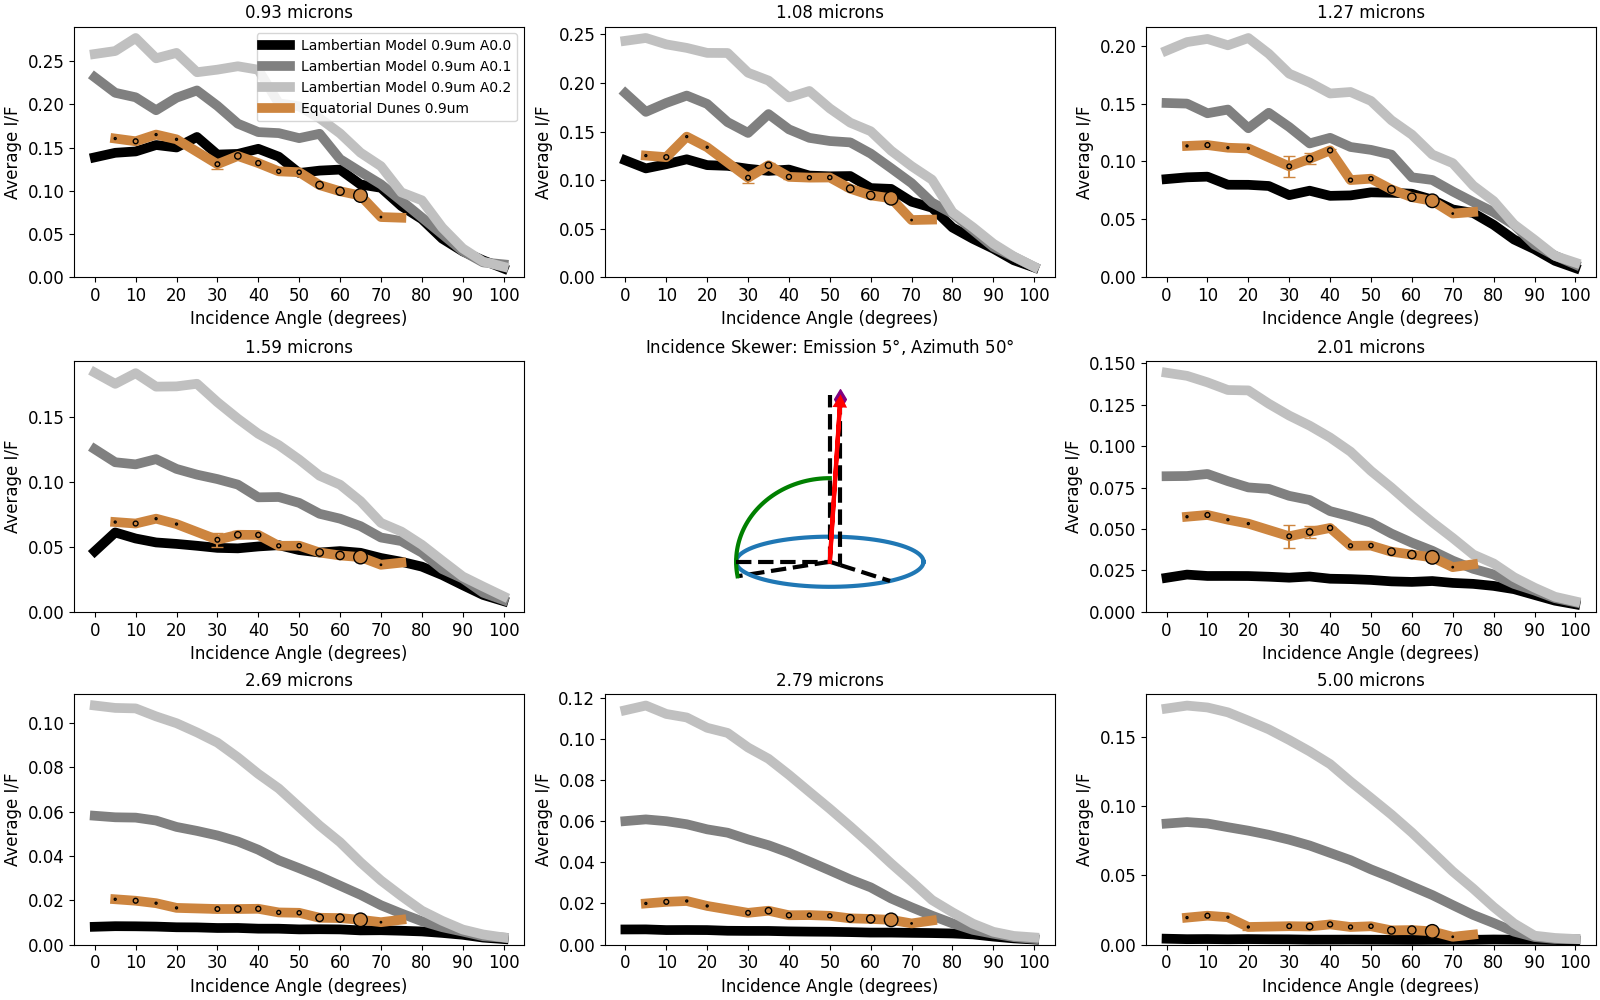

In [17]:
#NINE VIEW, SET EVERYTHING MANUALLY

#how many lines are we plotting? This is to say, how many different restricted BRDFs are we looking at?
#The maximum is five: three simulations, HLS, and the dunes.
lineCount = 4

incidence_deg = 35
emission_deg= 5
azimuth_deg = 50
type_call = "inci" #this should be "inci" "emis" or "azim"
output_filename = "ExampleSkewer.pdf" #Names of the saved produced file. 

# END OF PARAMETERS YOU NEED TO CARE ABOUT.

#To keep things consistent, do the following check:
if (type_call == "inci"): incidence_deg = 0 
if (type_call == "emis"): emission_deg = 0 
if (type_call == "azim"): azimuth_deg = 0 

%matplotlib ipympl
#Allows animation and interaction.

plt.close()

angleSpace = np.linspace(0, 180, 37)
inciSpace = np.linspace(0, 100, 21)
emisSpace = np.linspace(0, 90, 19)
azimSpace = np.linspace(0, 180, 37)
typeSpace = ["inci", "emis", "azim"]

def controllablePlotter(inci, emis, azim, types, model_index):
    model_data = loadedModels[model_index]
    mod = 1

    inci_idx = int(inci / 5)
    emis_idx = int(emis / 5)
    azim_idx = int(azim / 5)

    theLine = []
    if types == "inci":
        theLine = [model_data[i][emis_idx][azim_idx] * mod for i in range(21)]
    elif types == "emis":
        theLine = [model_data[inci_idx][i][azim_idx] * mod for i in range(19)]
    elif types == "azim":
        theLine = [model_data[inci_idx][emis_idx][i] * mod for i in range(37)]

    theLine_np = np.array(theLine, dtype=float)
    
    theLine_np[np.isclose(theLine_np, 0)] = np.nan 

    return theLine_np

def controllablePlotterScatter(inci, emis, azim, types, model_index):
    model_data = loadedModels[model_index]
    existence_checker = loadedModelCounts[model_index] #We should never call this when the index is set to "N" due to a check elsewhere. We SHOULD be fine, but this comment remains in case some unforseen circumstance arises.
    mod = 1

    inci_idx = int(inci / 5)
    emis_idx = int(emis / 5)
    azim_idx = int(azim / 5)

    theLine = []
    lineExistence = []
    if types == "inci":
        theLine = [model_data[i][emis_idx][azim_idx] * mod for i in range(21)]
        lineExistence = [existence_checker[i][emis_idx][azim_idx] * mod for i in range(21)]
    elif types == "emis":
        theLine = [model_data[inci_idx][i][azim_idx] * mod for i in range(19)]
        lineExistence = [existence_checker[inci_idx][i][azim_idx] * mod for i in range(19)]
    elif types == "azim":
        theLine = [model_data[inci_idx][emis_idx][i] * mod for i in range(37)]
        lineExistence = [existence_checker[inci_idx][emis_idx][i] * mod for i in range(37)]

    # Convert to a NumPy array to efficiently replace zeros with NaN
    theLine_np = np.array(theLine, dtype=float)
    theLine_np[np.isclose(theLine_np, 0)] = np.nan

    i = 0
    while (i < len(theLine_np)):
        if (lineExistence[i] <= 0):
            theLine_np[i] = np.nan
        i=i+1

    return theLine_np

def controllablePlotterErrors(inci, emis, azim, types, model_index):
    model_data = loadedModelStdevs[model_index]
    existence_checker = loadedModelCounts[model_index] #We should never call this when the index is set to "N" due to a check elsewhere. We SHOULD be fine, but this comment remains in case some unforseen circumstance arises.
    mod = 1

    inci_idx = int(inci / 5)
    emis_idx = int(emis / 5)
    azim_idx = int(azim / 5)

    theLine = []
    lineExistence = []
    if types == "inci":
        theLine = [model_data[i][emis_idx][azim_idx] * mod/np.sqrt(existence_checker[i][emis_idx][azim_idx]) for i in range(21)] #The division makes the error bars smaller.
        lineExistence = [existence_checker[i][emis_idx][azim_idx] * mod for i in range(21)]
    elif types == "emis":
        theLine = [model_data[inci_idx][i][azim_idx] * mod/np.sqrt(existence_checker[i][emis_idx][azim_idx]) for i in range(19)]
        lineExistence = [existence_checker[inci_idx][i][azim_idx] * mod for i in range(19)]
    elif types == "azim":
        theLine = [model_data[inci_idx][emis_idx][i] * mod/np.sqrt(existence_checker[i][emis_idx][azim_idx]) for i in range(37)]
        lineExistence = [existence_checker[inci_idx][emis_idx][i] * mod for i in range(37)]

    # Convert to a NumPy array to efficiently replace zeros with NaN
    theLine_np = np.array(theLine, dtype=float)
    theLine_np[np.isclose(theLine_np, 0)] = np.nan

    i = 0
    while (i < len(theLine_np)):
        if (lineExistence[i] <= 0):
            theLine_np[i] = np.nan
        i=i+1

    return theLine_np


def controllableSizer(inci, emis, azim, types, model_index,size_multiplier):
    existence_checker = loadedModelCounts[model_index]
    
    inci_idx = int(inci / 5)
    emis_idx = int(emis / 5)
    azim_idx = int(azim / 5)

    lineExistence = []
    if types == "inci":
        lineExistence = [existence_checker[i][emis_idx][azim_idx] for i in range(21)]
    elif types == "emis":
        lineExistence = [existence_checker[inci_idx][i][azim_idx] for i in range(19)]
    elif types == "azim":
        lineExistence = [existence_checker[inci_idx][emis_idx][i] for i in range(37)]

    sizes_np = np.array(lineExistence, dtype=float) * size_multiplier

    return sizes_np


# --- Main Plotting Logic ---
angleLabels = [0, 10, 20, 30, 40, 50, 60, 70,
               80, 90, 100, 110, 120, 130, 140, 150,
               160, 170, 180]

ticker = [0,2,4,6,8,10,12,14,16,18,20,22,24,26,28,30,32,34,36]

colors = ["black", "gray", "silver", "peru", "xkcd:brown", "xkcd:blue", "xkcd:red", "xkcd:pink", "xkcd:pink", "xkcd:brown", "xkcd:red",
          "xkcd:light blue", "xkcd:teal", "xkcd:orange", "xkcd:light green", "xkcd:magenta", "xkcd:yellow",
          "xkcd:sky blue", "xkcd:grey", "xkcd:lime green", "xkcd:light purple", "xkcd:violet", "xkcd:dark green",
          "xkcd:turquoise", "xkcd:lavender", "xkcd:dark blue", "xkcd:tan", "xkcd:cyan", "xkcd:aqua",
          "xkcd:forest green", "xkcd:mauve", "xkcd:dark purple", "xkcd:bright green", "xkcd:maroon", "xkcd:olive",
          "xkcd:salmon", "xkcd:beige", "xkcd:royal blue", "xkcd:navy blue", "xkcd:lilac", "xkcd:black",
          "xkcd:hot pink", "xkcd:light brown", "xkcd:pale green", "xkcd:peach", "xkcd:olive green", "xkcd:dark pink",
          "xkcd:periwinkle", "xkcd:sea green", "xkcd:lime", "xkcd:indigo", "xkcd:mustard", "xkcd:light pink"]

fig, axs = plt.subplots(3,3, figsize = (16,10), layout = "constrained") 

slider_formats = {"types": "{}"}


g = 0
h= 0
framecounter = 1 #because I can't be bothered with math at the moment, just keep track.
#Usiung these as indeces since we've already got some inside.
while (g < 3):
    while (h < 3):
        if ((g == 1) and (h == 1)):
            h=h+1
            framecounter = framecounter+1
        else:
            #Get the model index since we have to skip the middle.
            modelIndex = 0
            if (framecounter < 5):
                modelIndex = g*3 + h
            else:
                modelIndex = g*3 + h - 1
            # Plot the first model to generate the control widgets
            axs[g][h].plot(controllablePlotter(incidence_deg,emission_deg,azimuth_deg,type_call,modelIndex), label=modelNames[0][1], color=colors[0], linewidth=7)
            
            # Plot the rest of the models, linking them to the same controls
            for i in range(1, lineCount):
                j = modelIndex + i*8
                axs[g][h].plot(controllablePlotter(incidence_deg,emission_deg,azimuth_deg,type_call,j), label=modelNames[j][1], color=colors[i], linewidth=7)
            
            # Define a static x-axis that matches the implicit x-axis of the line plots.
            x_indices = []
            if (type_call == "inci"): x_indices = np.arange(21) 
            elif (type_call == "emis"): x_indices = np.arange(19) 
            elif (type_call == "azim"): x_indices = np.arange(37) 
            
            # --- CHANGE 1: Create an empty list to store the scatter artists ---
            scatter_artists = []
            
            # Now, add interactive scatter plots for the models that require them.
            for i in range(lineCount):
                j = modelIndex + i*8
                if (len(loadedModelCounts[j]) > 1):
                    # Provide a static X and a function for Y. This is a supported pattern.
                    axs[g][h].scatter(
                        x_indices,
                        controllablePlotterScatter(incidence_deg,emission_deg,azimuth_deg,type_call,j), 
                        color=colors[i],
                        s=controllableSizer(incidence_deg,emission_deg,azimuth_deg,type_call,j,1), 
                        zorder=5,
                        edgecolor = 'black'
                    )
                    new_artists = axs[0][0].collections[-2:]
                    for artist in new_artists:
                        artist.set_picker(5)
                    scatter_artists.extend(new_artists)
                    axs[g][h].errorbar(
                        x_indices,
                        controllablePlotterScatter(incidence_deg,emission_deg,azimuth_deg,type_call,j), 
                        controllablePlotterErrors(incidence_deg,emission_deg,azimuth_deg,type_call,j),
                        color=colors[i],
                        fmt='none', 
                        zorder=4,
                        capsize=4,
                    )
                    new_artists = axs[0][0].collections[-2:]
                    for artist in new_artists:
                        artist.set_picker(5)
                    scatter_artists.extend(new_artists)
            
            if (type_call == "inci"):
                axs[g][h].set(ylim=(0.0, None), xlabel="Incidence Angle (degrees)", ylabel="Average I/F", xticks=ticker[:11], xticklabels=angleLabels[:11])
                #ax.set_title("Incidence Slice at " +str(emission_deg)+ "° Emission " + str(azimuth_deg) + "° Azimuth", fontsize=20)
                axs[g][h].set_xlabel("Incidence Angle (degrees)", fontsize=12)
            elif (type_call == "emis"): 
                axs[g][h].set(ylim=(0.0, None), xlabel="Emission Angle (degrees)", ylabel="Average I/F", xticks=ticker[:10], xticklabels=angleLabels[:10])
                #ax.set_title("Emission Slice at " +str(incidence_deg)+ "° Incidence " + str(azimuth_deg) + "° Azimuth", fontsize=20)
                axs[g][h].set_xlabel("Emission Angle (degrees)", fontsize=12)
            elif (type_call == "azim"): 
                axs[g][h].set(ylim=(0.0, None), xlabel="Azimuth Angle (degrees)", ylabel="Average I/F", xticks=[0,4,8,12,16,20,24,28,32,36], xticklabels=[0, 20, 40, 60,
                           80, 100, 120, 140, 160, 180])
                #ax.set_title("Azimuth Slice at " +str(incidence_deg)+ "° Incidence " + str(emission_deg) + "° Emission", fontsize=20)
                axs[g][h].set_xlabel("Azimuth Angle (degrees)", fontsize=12)
            axs[g][h].set_ylabel("Average I/F", fontsize=12)
            axs[g][h].tick_params(axis='both', which='major', labelsize=12)
            h=h+1
            framecounter = framecounter+1
    g=g+1
    h=0

#THE CENTRAL GEOMETRY PLOT
#Inputs for what you want the plot to show.
#Named weirdly because this was originally two different programs I'm rather uglily smashing together here.
inciDeg = incidence_deg
emisDeg = emission_deg
azimDeg = azimuth_deg
emis = np.radians(emisDeg)
azim = np.radians(azimDeg)
inci = np.radians(inciDeg)

f = 0.3 #adjust for "scale" of pseudo-3D elipse.

lw = 3
if (type_call != "emis"):
    if (azimDeg >= 180): #Sometimes the detector is so close to the sun layering matters. 
        axs[1][1].scatter(math.sin(emis)*math.cos(azim),math.cos(emis) - f * math.sin(azim) * math.sin(emis),color="purple",s=100,marker = 'd',zorder = 0) #Placement of the satelite, which can change with emission and azimuth.
    else:
        axs[1][1].scatter(math.sin(emis)*math.cos(azim),math.cos(emis) - f * math.sin(azim) * math.sin(emis),color="purple",s=100,marker = 'd') #Placement of the satelite, which can change with emission and azimuth.
    axs[1][1].arrow(0,0,math.sin(emis)*math.cos(azim),math.cos(emis) - f * math.sin(azim)* math.sin(emis),color="red",head_width=0.04,head_length=0.04,length_includes_head=True, linewidth = lw,zorder=11)
    #Arrow pointing from ground to detector.

if (type_call != "inci"):
    axs[1][1].scatter(-math.sin(inci),math.cos(inci),color="gold",s=500) #The sun's placement is dependent upon the incidence angle, but none of the others. 
    axs[1][1].arrow(-math.sin(inci),math.cos(inci),math.sin(inci),-math.cos(inci),color="red",head_width=0.04,head_length=0.04,length_includes_head=True, linewidth = lw) #Arrow pointing from sun to ground.

#The incidence line.
if (type_call == "inci"):
    axs[1][1].plot([0,-0.5*math.sin(np.radians(100))],[0,0.5*math.cos(np.radians(100))],linestyle='--',color = 'black', linewidth = lw)

#Pseudo 3D Ellipse
u=0.     #x-position of the center
v=0.    #y-position of the center
a=0.5     #radius on the x-axis
b=f/2.    #radius on the y-axis
t = np.linspace(0, 2*np.pi, 100)
axs[1][1].plot( u+a*np.cos(t) , v+b*np.sin(t), linewidth = lw)

if (type_call == "inci"):
    u=0.     #x-position of the center
    v=0.    #y-position of the center
    r=0.5     #radius on the x-axis
    t = np.linspace(np.pi/2, np.pi+0.1745329252, 50)
    axs[1][1].plot( u+r*np.cos(t) , v+r*np.sin(t), color = "green", linewidth = lw)

if (type_call == "emis"):
    u=0.     #x-position of the center
    v=0.    #y-position of the center
    a=0.5*np.cos(azim)      #radius on the x-axis
    b=0.5   #radius on the y-axis
    t = np.linspace(-np.sin(azim)/np.pi, np.pi/2, 50)
    if (azimDeg >= 180):    
        axs[1][1].plot( u+a*np.cos(t) , v+b*np.sin(t), color = "green", zorder = 0, linewidth = lw)
    else: 
        axs[1][1].plot( u+a*np.cos(t) , v+b*np.sin(t), color = "green", linewidth = lw)  

if (type_call == "azim"):
    u=0.     #x-position of the center
    v=0.    #y-position of the center
    a=0.25     #radius on the x-axis
    b=f/4.    #radius on the y-axis
    t = np.linspace(0, 2*np.pi, 100)
    axs[1][1].plot( u+a*np.cos(t) , v+b*np.sin(t), color = "green", zorder = 0, linewidth = lw)
    axs[1][1].arrow(-0.03,-f/4.,-0.00001,0.,color="green",head_width=0.04,head_length=0.04,length_includes_head=True, linewidth = lw)
    axs[1][1].arrow(0.03,f/4.,0.00001,0.,color="green",head_width=0.04,head_length=0.04,length_includes_head=True,zorder=0, linewidth = lw)

#The normal line.
axs[1][1].plot([0,0],[0,1],linestyle='--',color = 'black', linewidth = lw)

#Triangles to make the 3D arrangement of points clear.
if (type_call == "inci"):
    axs[1][1].plot([math.sin(emis)*math.cos(azim),math.sin(emis)*math.cos(azim)],[math.cos(emis) - f * math.sin(azim) * math.sin(emis),- f * math.sin(azim) * math.sin(emis)],linestyle='--',color = 'black', linewidth = lw)
    axs[1][1].plot([-0.5,0.0],[0,0],linestyle='--',color = 'black', linewidth = lw)
    if (azimDeg != 0):
        axs[1][1].plot([math.sin(emis)*math.cos(azim),0],[- f * math.sin(azim) * math.sin(emis),0],linestyle='--',color = 'black', linewidth = lw)
    if (emisDeg < 30):
        axs[1][1].plot([math.sin(emis)*math.cos(azim),math.sin(np.radians(30))*math.cos(azim)],[- f * math.sin(azim) * math.sin(emis),- f * math.sin(azim) * math.sin(np.radians(30))],linestyle='--',color = 'black', linewidth = lw)

if (type_call == "emis"):
    if (azimDeg != 0):
        axs[1][1].plot([math.sin(np.radians(30))*math.cos(azim),0],[- f * math.sin(azim) * math.sin(np.radians(30)),0],linestyle='--',color = 'black', linewidth = lw)
    axs[1][1].plot([0.0,0.5],[0,0],linestyle='--',color = 'black', linewidth = lw) #This line always exists, it's where the azimuth is measured from.
    axs[1][1].plot([-math.sin(inci),-math.sin(inci)],[math.cos(inci),0],linestyle='--',color = 'black', linewidth = lw)
    axs[1][1].plot([-math.sin(inci),0.],[0,0],linestyle='--',color = 'black', linewidth = lw)
    if (inciDeg < 30): #Sometimes the triangles are smaller than the ellipse, so when they are make sure to still draw the reference lines to the edge.
        axs[1][1].plot([-0.5,-math.sin(inci)],[0,0],linestyle='--',color = 'black', linewidth = lw)    

if (type_call == "azim"):
    axs[1][1].plot([math.sin(emis)*math.cos(0),math.sin(emis)*math.cos(0)],[math.cos(emis) - f * math.sin(0) * math.sin(emis),- f * math.sin(0) * math.sin(emis)],linestyle='--',color = 'black', linewidth = lw)
    axs[1][1].plot([-math.sin(inci),-math.sin(inci)],[math.cos(inci),0],linestyle='--',color = 'black', linewidth = lw)
    axs[1][1].plot([-math.sin(inci),0.],[0,0],linestyle='--',color = 'black', linewidth = lw)
    axs[1][1].plot([math.sin(emis),0.],[0,0],linestyle='--',color = 'black', linewidth = lw) #THIS LINE IS SUSPECT REMOVE IF THINGS BREAK
    if (inciDeg < 30): #Sometimes the triangles are smaller than the ellipse, so when they are make sure to still draw the reference lines to the edge.
        axs[1][1].plot([-0.5,-math.sin(inci)],[0,0],linestyle='--',color = 'black', linewidth = lw)
    if (emisDeg < 30):
        axs[1][1].plot([math.sin(emis)*math.cos(0),math.sin(np.radians(30))*math.cos(0)],[- f * math.sin(0) * math.sin(emis),- f * math.sin(0) * math.sin(np.radians(30))],linestyle='--',color = 'black', linewidth = lw)

if (type_call == "inci"):
    axs[1][1].set(ylim = [-0.3,1.2], xlim = [-1.2, 1.2], xticks = [], yticks = [], title="Incidence Skewer: Emission "+ str(emisDeg) + "$\degree$, Azimuth " + str(azimDeg) + "$\degree$")
elif (type_call == "emis"):
    axs[1][1].set(ylim = [-0.3,1.2], xlim = [-1.2, 1.2], xticks = [], yticks = [], title="Emission Skewer: Incidence "+ str(inciDeg) + "$\degree$, Azimuth " + str(azimDeg) + "$\degree$")
elif (type_call == "azim"):
    axs[1][1].set(ylim = [-0.3,1.2], xlim = [-1.2, 1.2], xticks = [], yticks = [], title="Azimuth Skewer: Incidence "+ str(inciDeg) + "$\degree$, Emission " + str(emisDeg) + "$\degree$")

axs[1][1].axis('off') #remove border and ticks. 

axs[0][0].set(title = "0.93 microns")
axs[0][1].set(title = "1.08 microns")
axs[0][2].set(title = "1.27 microns")
axs[1][0].set(title = "1.59 microns")
axs[1][2].set(title = "2.01 microns")
axs[2][0].set(title = "2.69 microns")
axs[2][1].set(title = "2.79 microns")
axs[2][2].set(title = "5.00 microns")

axs[0][0].legend()

plt.savefig(output_filename, format='pdf', bbox_inches='tight')

plt.show() 